In [5]:
import argparse
import cv2
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
from dataclasses import dataclass
import os
import matplotlib

In [6]:
@dataclass
class Component:
    """Class to store connected component information"""
    bbox: Tuple[int, int, int, int]  # x, y, w, h
    centroid: Tuple[float, float]
    area: int
    contour_length: int

In [7]:
def kfill(binary_image, k=5, max_iterations=10):
    """
    Implement the kFill filter for noise reduction in binary document images.
    This is the Will filter mentioned in the paper.
    
    Args:
        binary_image (numpy.ndarray): Binary image (1 for foreground, 0 for background).
        k (int): Window size parameter (must be odd).
        max_iterations (int): Maximum number of iterations to perform.
        
    Returns:
        numpy.ndarray: Filtered binary image.
    """
    # Ensure k is odd
    if k % 2 == 0:
        k = k + 1
    
    # Create a copy of the image
    filtered_image = binary_image.copy()
    
    iteration = 0
    changes_made = True
    
    # Continue until no changes or max iterations reached
    while changes_made and iteration < max_iterations:
        changes_made = False
        iteration += 1
        
        # Perform ON-fill and OFF-fill sub-iterations
        for fill_value in [1, 0]:  # 1 for ON-fill, 0 for OFF-fill
            height, width = filtered_image.shape
            
            # Create a copy to store changes for this sub-iteration
            temp_image = filtered_image.copy()
            
            # Process each pixel
            for y in range(k//2, height - k//2):
                for x in range(k//2, width - k//2):
                    # Extract window
                    window = filtered_image[y - k//2 : y + k//2 + 1, x - k//2 : x + k//2 + 1]
                    
                    # Define core and neighborhood
                    core = window[1:-1, 1:-1]
                    
                    # Only proceed if all core values are opposite of fill_value
                    if fill_value == 1 and np.any(core == 1):
                        continue
                    if fill_value == 0 and np.any(core == 0):
                        continue
                    
                    # Extract neighborhood (perimeter of window)
                    neighborhood = np.concatenate([
                        window[0, :],                # Top row
                        window[-1, :],               # Bottom row
                        window[1:-1, 0],             # Left column (without corners)
                        window[1:-1, -1]             # Right column (without corners)
                    ])
                    
                    # Calculate n (number of ON or OFF pixels in neighborhood)
                    if fill_value == 1:
                        n = np.sum(neighborhood == 1)  # Count ON pixels
                    else:
                        n = np.sum(neighborhood == 0)  # Count OFF pixels
                    
                    # Calculate c (number of connected groups in neighborhood)
                    # We need to analyze the neighborhood as a circular list
                    expanded_neighborhood = np.concatenate([neighborhood, neighborhood[0:1]])
                    c = 0
                    for i in range(len(neighborhood)):
                        if expanded_neighborhood[i] != expanded_neighborhood[i+1]:
                            c += 1
                    c = c // 2  # Each transition is counted twice (ON->OFF and OFF->ON)
                    
                    # Calculate r (number of corner pixels that are ON or OFF)
                    corners = [window[0, 0], window[0, -1], window[-1, 0], window[-1, -1]]
                    if fill_value == 1:
                        r = sum(1 for corner in corners if corner == 1)
                    else:
                        r = sum(1 for corner in corners if corner == 0)
                    
                    # Apply kFill condition: (c = 1) AND [(n > 3k - 4) OR (n = 3k - 4) AND r = 2]
                    if (c == 1) and ((n > 3*k - 4) or ((n == 3*k - 4) and (r == 2))):
                        # Fill the core
                        temp_image[y - k//2 + 1 : y + k//2, x - k//2 + 1 : x + k//2] = fill_value
                        changes_made = True
            
            # Update filtered_image with the results of this sub-iteration
            filtered_image = temp_image.copy()
    
    return filtered_image

def generate_distinct_colors(n_colors: int) -> np.ndarray:
    """
    Generate distinct, easily visible colors for block visualization
    
    Args:
        n_colors: Number of colors needed
        
    Returns:
        numpy.ndarray: Array of RGB colors scaled to 0-255 range
    """
    # Use a colormap that provides good contrast
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    
    # If we need more colors, add more colormaps
    if n_colors > 20:
        # Add colors from Dark2 colormap
        base = np.vstack((base, plt.cm.Dark2(np.linspace(0, 1, 8))))
    if n_colors > 28:
        # Add colors from Set1 colormap
        base = np.vstack((base, plt.cm.Set1(np.linspace(0, 1, 9))))
        
    # Ensure minimum brightness and contrast
    min_brightness = 0.3  # Minimum brightness threshold
    max_brightness = 0.9  # Maximum brightness threshold
    
    # Adjust colors
    for i in range(len(base)):
        # Calculate perceived brightness (using common weights)
        brightness = 0.299 * base[i,0] + 0.587 * base[i,1] + 0.114 * base[i,2]
        
        # Adjust too dark colors
        if brightness < min_brightness:
            scale = min_brightness / (brightness + 1e-6)
            base[i,:3] = np.minimum(base[i,:3] * scale, 1.0)
            
        # Adjust too light colors
        if brightness > max_brightness:
            scale = max_brightness / (brightness + 1e-6)
            base[i,:3] = base[i,:3] * scale
    
    # If we still need more colors, create variations of existing ones
    while len(base) < n_colors:
        additional = base[:n_colors-len(base)]
        # Create variations by adjusting hue
        hsv = matplotlib.colors.rgb_to_hsv(additional[:,:3])
        hsv[:,0] = (hsv[:,0] + 0.5) % 1.0  # Shift hue by 0.5
        rgb = matplotlib.colors.hsv_to_rgb(hsv)
        additional[:,:3] = rgb
        base = np.vstack((base, additional))
    
    # Convert to 0-255 range and return required number of colors
    colors = (base[:n_colors, :3] * 255).astype(int)
    return colors

In [24]:

class Docstrum:
    def __init__(self, k_nearest: int = 5, angle_threshold: float = 30):
        """
        Initialize docstrum processor
        
        Args:
            k_nearest: Number of nearest neighbors to find (default 5)
            angle_threshold: Angle threshold in degrees for within-line connections
        """
        self.k = k_nearest
        self.angle_threshold = angle_threshold

    def preprocess(self, image: np.ndarray, kfill_threshold = 5, max_iterations = 10) -> np.ndarray:
        """
        Preprocess the image - noise reduction and binarization as described in the paper.
        
        Args:
            image: Input grayscale image
            
        Returns:
            Binary image
        """
        # Apply Otsu's thresholding
        _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Invert if needed (assuming text is black)
        if np.mean(binary) > 127:
            binary = cv2.bitwise_not(binary)
            
        # Convert to binary format (0 and 1)
        binary = (binary > 0).astype(np.uint8)
        
        # Apply the Will filter (kFill) for noise reduction as mentioned in the paper
        binary = kfill(binary, k= kfill_threshold, max_iterations= max_iterations)
        
        return binary
    
    def size_filtering(self, components: List[Component]) -> List[Component]:
        """
        Filter components based on size histogram as described in the paper.
        
        Args:
            components: List of components
            
        Returns:
            Filtered list of components
        """
        if not components:
            return []
            
        # Calculate size for each component (square root of bounding box area)
        sizes = [np.sqrt(comp.bbox[2] * comp.bbox[3]) for comp in components]
        
        # Create histogram of sizes
        hist, bins = np.histogram(sizes, bins='auto')
        
        # Find the peak for predominant font size
        peak_idx = np.argmax(hist)
        peak_size = (bins[peak_idx] + bins[peak_idx + 1]) / 2
        
        # Filter components - keep those within a reasonable range of peak size
        # Paper suggests keeping components in the predominant size range
        filtered_components = []
        min_size = peak_size / 10  # Allow for subscripts/small characters
        max_size = peak_size * 10  # Allow for larger characters but not titles
        
        for i, comp in enumerate(components):
            if min_size <= sizes[i] <= max_size:
                filtered_components.append(comp)
        
        return filtered_components

    def find_connected_components(self, binary: np.ndarray) -> List[Component]:
        """
        Find connected components in binary image using contours as described in the paper.
        The paper mentions using "thin line code" (TLC), but we'll use OpenCV contours
        which provide the necessary features.
        
        Args:
            binary: Binary image
            
        Returns:
            List of Component objects
        """
        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        
        components = []
        for contour in contours:
            # Calculate bounding box
            x, y, w, h = cv2.boundingRect(contour)
            
            # Calculate centroid
            M = cv2.moments(contour)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
            else:
                cx, cy = x + w // 2, y + h // 2
            
            # Calculate area and contour length
            area = cv2.contourArea(contour)
            contour_length = cv2.arcLength(contour, True)
            
            # Create component
            component = Component(
                bbox=(x, y, w, h),
                centroid=(cx, cy),
                area=area,
                contour_length=contour_length
            )
            
            components.append(component)
        
        # Apply size filtering as described in the paper
        filtered_components = self.size_filtering(components)
        
        return filtered_components
    


    def find_nearest_neighbors(self, components: List[Component]) -> List[List[Tuple[int, float, float]]]:
        """
        Find k nearest neighbors for each component
        
        Args:
            components: List of components
            
        Returns:
            List of lists containing (neighbor_idx, distance, angle) tuples for each component
        """
        if len(components) < self.k + 1:
            raise ValueError(f"Not enough components ({len(components)}) for k={self.k} nearest neighbors")
            
        # Extract centroids
        points = np.array([c.centroid for c in components])
        
        # Adjust k if necessary
        k = min(self.k + 1, len(components))
        print(f"Finding {k-1} nearest neighbors for each component")
        
        # Build KD-tree for efficient nearest neighbor search
        tree = KDTree(points)
        
        # Find k nearest neighbors (first one is the point itself)
        distances, indices = tree.query(points, k=k)
        
        neighbors_info = []
        for i, (component_neighbors, neighbor_distances) in enumerate(zip(indices, distances)):
            # Skip the first neighbor (point itself)
            neighbors = []
            for j, (neighbor_idx, dist) in enumerate(zip(component_neighbors[1:], neighbor_distances[1:]), 1):
                # Calculate angle between components
                dx = points[neighbor_idx][0] - points[i][0]
                dy = points[neighbor_idx][1] - points[i][1]
                angle = np.degrees(np.arctan2(dy, dx)) % 180
                
                neighbors.append((neighbor_idx, dist, angle))
            
            neighbors_info.append(neighbors)
            
        return neighbors_info


    def estimate_orientation(self, neighbors_info: List[List[Tuple[int, float, float]]], smoothing_window: int = 25) -> float:
        """
        Estimate document orientation from neighbor angles as described in the paper.
        
        Args:
            neighbors_info: List of neighbor information
            smoothing_window: Size of the smoothing window (default 25)
            
        Returns:
            Estimated orientation angle in degrees
        """
        # Collect all angles
        angles = []
        for component_neighbors in neighbors_info:
            angles.extend([n[2] for n in component_neighbors])
            
        # Create histogram of angles
        hist, bins = np.histogram(angles, bins=180, range=(0, 180))
        
        # Apply circular smoothing as described in the paper
        smoothed_hist = np.zeros_like(hist, dtype=float)
        
        for i in range(len(hist)):
            sum_val = 0
            count = 0
            for j in range(i - smoothing_window // 2, i + smoothing_window // 2 + 1):
                # Handle circular wrapping
                wrapped_j = j % len(hist)
                sum_val += hist[wrapped_j]
                count += 1
            smoothed_hist[i] = sum_val / count
        
        # Find peak in smoothed histogram
        peak_idx = np.argmax(smoothed_hist)
        orientation = bins[peak_idx] + (bins[peak_idx+1] - bins[peak_idx]) / 2
        
        return orientation

    def estimate_spacing(self, neighbors_info: List[List[Tuple[int, float, float]]], 
                        orientation: float) -> Tuple[float, float]:
        """
        Estimate within-line and between-line spacing as described in the paper.
        
        Args:
            neighbors_info: List of neighbor information
            orientation: Estimated text orientation
            
        Returns:
            Tuple of (within_line_spacing, between_line_spacing)
        """
        # Define angular range for within-line neighbors
        angle_tolerance = self.angle_threshold
        within_line_angles = [(orientation - angle_tolerance) % 180, 
                             (orientation + angle_tolerance) % 180]
        
        # Define angular range for between-line neighbors
        between_line_orientation = (orientation + 90) % 180
        between_line_angles = [(between_line_orientation - angle_tolerance) % 180, 
                              (between_line_orientation + angle_tolerance) % 180]
        
        # Collect distances for within-line and between-line neighbors
        within_line_distances = []
        between_line_distances = []
        
        for component_neighbors in neighbors_info:
            for _, dist, angle in component_neighbors:
                # Handle circular angle comparisons
                def is_in_range(a, range_start, range_end):
                    if range_start <= range_end:
                        return range_start <= a <= range_end
                    else:  # Range wraps around 180
                        return range_start <= a <= 180 or 0 <= a <= range_end
                
                # Check if within line
                if is_in_range(angle, within_line_angles[0], within_line_angles[1]) or \
                   is_in_range((angle + 180) % 180, within_line_angles[0], within_line_angles[1]):
                    within_line_distances.append(dist)
                
                # Check if between line
                elif is_in_range(angle, between_line_angles[0], between_line_angles[1]) or \
                     is_in_range((angle + 180) % 180, between_line_angles[0], between_line_angles[1]):
                    between_line_distances.append(dist)
        
        # Create histograms with proper resolution and smoothing as described in the paper
        def find_spacing_from_histogram(distances):
            if not distances:
                return 0
                
            # Use 2 pixels/bin resolution as mentioned in the paper
            hist, bins = np.histogram(distances, bins=np.arange(0, max(distances) + 2, 2))
            
            # Apply smoothing with a window of 5 bins
            smoothed_hist = np.convolve(hist, np.ones(5)/5, mode='same')
            
            # Find peak
            peak_idx = np.argmax(smoothed_hist)
            spacing = bins[peak_idx] + (bins[peak_idx+1] - bins[peak_idx]) / 2
            
            return spacing
        
        within_line_spacing = find_spacing_from_histogram(within_line_distances)
        between_line_spacing = find_spacing_from_histogram(between_line_distances)
        
        return within_line_spacing, between_line_spacing

    def find_text_lines(self, components: List[Component], 
                      neighbors_info: List[List[Tuple[int, float, float]]], 
                      orientation: float) -> List[List[int]]:
        """
        Group components into text lines as described in the paper.
        
        Args:
            components: List of components
            neighbors_info: List of neighbor information
            orientation: Estimated text orientation
                
        Returns:
            List of text lines, where each line is a list of component indices
        """
        # Build graph of connected components for within-line neighbors
        graph = {i: set() for i in range(len(components))}
        
        for i, component_neighbors in enumerate(neighbors_info):
            for neighbor_idx, _, angle in component_neighbors:
                # Check if angle is within threshold of orientation
                angle_diff = min((angle - orientation) % 180, (orientation - angle) % 180)
                if angle_diff < self.angle_threshold:
                    graph[i].add(neighbor_idx)
                    graph[neighbor_idx].add(i)
        
        # Perform transitive closure to find connected components (text lines)
        # This is exactly as described in the paper
        visited = set()
        text_lines = []
        
        def dfs(node, current_line):
            visited.add(node)
            current_line.append(node)
            for neighbor in graph[node]:
                if neighbor not in visited:
                    dfs(neighbor, current_line)
        
        for i in range(len(components)):
            if i not in visited:
                current_line = []
                dfs(i, current_line)
                text_lines.append(current_line)
        
        # Perform linear regression to get more accurate text lines as described in the paper
        refined_lines = []
        for line in text_lines:
            if len(line) < 2:
                refined_lines.append(line)
                continue
                
            # Extract centroids for regression
            centroids = np.array([components[idx].centroid for idx in line])
            x = centroids[:, 0]
            y = centroids[:, 1]
            
            # Perform linear regression
            A = np.vstack([x, np.ones(len(x))]).T
            m, c = np.linalg.lstsq(A, y, rcond=None)[0]
            
            # Sort components by x-coordinate for left-to-right reading
            sorted_line = sorted(line, key=lambda idx: components[idx].centroid[0])
            refined_lines.append(sorted_line)
        
        # Sort text lines by y-coordinate (top to bottom)
        # This matches the reading order mentioned in the paper
        refined_lines.sort(key=lambda line: np.mean([components[idx].centroid[1] for idx in line]))
        
        return refined_lines

    def find_accurate_orientation(self, components: List[Component], text_lines: List[List[int]]) -> float:
        """
        Make a more accurate orientation measurement using text lines as described in the paper.
        
        Args:
            components: List of components
            text_lines: List of text lines
            
        Returns:
            Refined orientation estimate in degrees
        """
        if not text_lines:
            return 0
            
        # Only use long text lines for better accuracy as implied in the paper
        long_lines = [line for line in text_lines if len(line) >= 5]
        if not long_lines:
            long_lines = text_lines
            
        # Calculate orientation for each line
        orientations = []
        for line in long_lines:
            if len(line) < 2:
                continue
                
            # Extract centroids
            centroids = [components[idx].centroid for idx in line]
            
            # Calculate orientation via linear regression
            x = [c[0] for c in centroids]
            y = [c[1] for c in centroids]
            
            if len(set(x)) < 2:  # Avoid vertical lines
                continue
                
            # Fit line
            A = np.vstack([x, np.ones(len(x))]).T
            m, c = np.linalg.lstsq(A, y, rcond=None)[0]
            
            # Convert slope to angle
            angle = np.degrees(np.arctan(m)) % 180
            orientations.append(angle)
        
        if not orientations:
            return 0
            
        # Return median orientation for robustness
        return np.median(orientations)

    def find_blocks(self, components: List[Component], text_lines: List[List[int]], 
                  orientation: float, 
                  within_line_spacing: float, 
                  between_line_spacing: float) -> List[List[List[int]]]:
        """
        Group text lines into blocks based on the criteria in the paper:
        1. Parallelness
        2. Perpendicular proximity
        3. Overlap
        4. Parallel proximity
        
        Args:
            components: List of components
            text_lines: List of text lines
            orientation: Refined orientation estimate
            within_line_spacing: Estimated within-line spacing
            between_line_spacing: Estimated between-line spacing
            
        Returns:
            List of blocks, where each block is a list of text lines
        """
        if not text_lines:
            return []
        
        # Define parameters based on spacing values as mentioned in the paper
        perpendicular_threshold = 1.3 * between_line_spacing
        parallel_threshold = 1.5 * within_line_spacing
        
        # Get line bounds
        line_bounds = []
        for line in text_lines:
            if not line:
                line_bounds.append((0, 0, 0, 0))
                continue
                
            min_x = min(components[idx].bbox[0] for idx in line)
            min_y = min(components[idx].bbox[1] for idx in line)
            max_x = max(components[idx].bbox[0] + components[idx].bbox[2] for idx in line)
            max_y = max(components[idx].bbox[1] + components[idx].bbox[3] for idx in line)
            line_bounds.append((min_x, min_y, max_x, max_y))
        
        # Initialize blocks - each text line starts as its own block
        blocks = [[line] for line in text_lines]
        block_bounds = line_bounds.copy()
        
        # Merge blocks according to the criteria described in the paper
        while True:
            merged = False
            
            for i in range(len(blocks)):
                if merged:
                    break
                    
                for j in range(i + 1, len(blocks)):
                    # Get bounds
                    bounds_i = block_bounds[i]
                    bounds_j = block_bounds[j]
                    
                    # Check criteria
                    
                    # 1. Parallelness - assumed for same document, so always true
                    
                    # 2. Perpendicular proximity
                    perp_distance = min(abs(bounds_i[3] - bounds_j[1]), abs(bounds_i[1] - bounds_j[3]))
                    
                    # 3. Overlap - check horizontal overlap
                    x_overlap = min(bounds_i[2], bounds_j[2]) - max(bounds_i[0], bounds_j[0])
                    has_overlap = x_overlap > 0
                    
                    # 4. Parallel proximity - check horizontal distance
                    if bounds_i[2] < bounds_j[0]:  # block i is to the left of block j
                        para_distance = bounds_j[0] - bounds_i[2]
                    elif bounds_j[2] < bounds_i[0]:  # block j is to the left of block i
                        para_distance = bounds_i[0] - bounds_j[2]
                    else:  # Blocks overlap horizontally
                        para_distance = 0
                    
                    # Apply the criteria
                    if perp_distance <= perpendicular_threshold and (has_overlap or para_distance <= parallel_threshold):
                        # Merge blocks
                        blocks[i].extend(blocks[j])
                        blocks.pop(j)
                        
                        # Update bounds
                        min_x = min(bounds_i[0], bounds_j[0])
                        min_y = min(bounds_i[1], bounds_j[1])
                        max_x = max(bounds_i[2], bounds_j[2])
                        max_y = max(bounds_i[3], bounds_j[3])
                        block_bounds[i] = (min_x, min_y, max_x, max_y)
                        block_bounds.pop(j)
                        
                        merged = True
                        break
            
            if not merged:
                break
        
        return blocks

    def process(self, image: np.ndarray, kfill_threshold = 5, max_iterations = 10):
        """
        Process image with the docstrum algorithm
        
        Args:
            image: Input grayscale image
            
        Returns:
            Tuple containing components, text lines, orientation, blocks, and spacings
        """
        # Preprocess image
        binary = self.preprocess(image, kfill_threshold = kfill_threshold, max_iterations = max_iterations)
        
        # Find connected components
        components = self.find_connected_components(binary)
        
        # Find k-nearest neighbors
        neighbors_info = self.find_nearest_neighbors(components)
        
        # Estimate orientation
        initial_orientation = self.estimate_orientation(neighbors_info)
        
        # Estimate spacing
        within_line_spacing, between_line_spacing = self.estimate_spacing(neighbors_info, initial_orientation)
        
        # Find text lines
        text_lines = self.find_text_lines(components, neighbors_info, initial_orientation)
        
        # Make more accurate orientation measurement using text lines
        final_orientation = self.find_accurate_orientation(components, text_lines)
        
        # Find blocks
        blocks = self.find_blocks(components, text_lines, final_orientation, within_line_spacing, between_line_spacing)
        
        return components, text_lines, final_orientation, blocks, (within_line_spacing, between_line_spacing), binary, initial_orientation, neighbors_info

    # New visualization functions inspired by the second script

    def visualize_preprocessing(self, image: np.ndarray, binary: np.ndarray, output_dir: str, filename: str):
        """
        Visualize and save the preprocessing step binary image with same resolution as input
        
        Args:
            image: Original grayscale image
            binary: Preprocessed binary image
            output_dir: Output directory path
            filename: Base filename for the output
        """
        # Get original image dimensions
        h, w = image.shape[:2]
        
        # Create a figure with same aspect ratio
        fig = plt.figure(frameon=False)
        fig.set_size_inches(w/100, h/100)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)
        
        # Display binary image
        ax.imshow(binary, cmap='gray', aspect='auto')
        
        # Save the figure with the same resolution as the input image
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f'{filename}_preprocessing.png')
        # plt.savefig(output_path, dpi=100, bbox_inches='tight', pad_inches=0)
        # plt.close(fig)
        plt.show()
        
    def visualize_components(self, image: np.ndarray, components: List[Component], output_dir: str, filename: str):
        """
        Visualize and save detected connected components with bounding boxes and centroids
        
        Args:
            image: Original grayscale image
            components: List of components
            output_dir: Output directory path
            filename: Base filename for the output
        """
        # Create RGB visualization image
        vis_image = cv2.cvtColor(image.copy(), cv2.COLOR_GRAY2RGB)
        
        # Generate distinct colors
        colors = plt.cm.rainbow(np.linspace(0, 1, len(components)))
        colors = (colors[:, :3] * 255).astype(int)
        
        # Draw components
        for idx, comp in enumerate(components):
            color = colors[idx % len(colors)].tolist()
            x, y, w, h = comp.bbox
            
            # Draw bounding box
            cv2.rectangle(vis_image, (x, y), (x + w, y + h), color, 1)
            
            # Draw centroid
            cx, cy = map(int, comp.centroid)
            cv2.circle(vis_image, (cx, cy), 2, color, -1)
        
        # Get original image dimensions
        h, w = image.shape[:2]
        
        # Create a figure with same aspect ratio
        fig = plt.figure(frameon=False)
        fig.set_size_inches(w/100, h/100)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)
        
        # Display the visualization
        ax.imshow(vis_image)
        
        # Save the figure with the same resolution as the input image
        os.makedirs(output_dir, exist_ok=True)
        # output_path = os.path.join(output_dir, f'{filename}_components.png')
        # plt.savefig(output_path, dpi=100, bbox_inches='tight', pad_inches=0)
        # plt.close(fig)
        plt.show()
        
    def visualize_neighbors(self, image: np.ndarray, components: List[Component], 
                           neighbors_info: List[List[Tuple[int, float, float]]], 
                           output_dir: str, filename: str):
        """
        Visualize and save k-nearest neighbors connections between components
        
        Args:
            image: Original grayscale image
            components: List of components
            neighbors_info: List of neighbor information
            output_dir: Output directory path
            filename: Base filename for the output
        """
        # Create RGB visualization image
        vis_image = cv2.cvtColor(image.copy(), cv2.COLOR_GRAY2RGB)
        
        # Draw connections between components
        for i, component_neighbors in enumerate(neighbors_info):
            x1, y1 = map(int, components[i].centroid)
            
            for neighbor_idx, dist, angle in component_neighbors:
                x2, y2 = map(int, components[neighbor_idx].centroid)
                
                # Color based on angle (cyclic color map)
                color = plt.cm.hsv(angle / 180)[:3]
                color = tuple(int(c * 255) for c in color)
                
                # Draw line connecting components
                cv2.line(vis_image, (x1, y1), (x2, y2), color, 1, cv2.LINE_AA)
        
        # Draw component centroids on top
        for comp in components:
            cx, cy = map(int, comp.centroid)
            cv2.circle(vis_image, (cx, cy), 2, (255, 0, 0), -1)
        
        # Get original image dimensions
        h, w = image.shape[:2]
        
        # Create a figure with same aspect ratio
        fig = plt.figure(frameon=False)
        fig.set_size_inches(w/100, h/100)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)
        
        # Display the visualization
        ax.imshow(vis_image)
        
        # Save the figure with the same resolution as the input image
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f'{filename}_neighbors.png')
        # plt.savefig(output_path, dpi=100, bbox_inches='tight', pad_inches=0)
        # plt.close(fig)
        plt.show()
        
        # Save a separate figure with colorbar for reference (not constrained by resolution)
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(vis_image)
        ax.set_title('K-Nearest Neighbors Connections')
        ax.axis('off')
        
        # Create a separate axes for the colorbar
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
        
        # Create a color mesh for the colorbar
        norm = plt.Normalize(0, 180)
        sm = plt.cm.ScalarMappable(cmap=plt.cm.hsv, norm=norm)
        sm.set_array([])  # This is a workaround to make the colorbar work
        
        # Add colorbar to the axes
        cbar = fig.colorbar(sm, cax=cbar_ax)
        cbar.set_label('Angle (degrees)')
        
        # Save the figure with colorbar (not constrained by resolution)
        colorbar_path = os.path.join(output_dir, f'{filename}_neighbors_with_colorbar.png')
        # plt.savefig(colorbar_path, dpi=300, bbox_inches='tight')
        # plt.close(fig)
        plt.show()
        
    def visualize_orientation_histogram(self, neighbors_info: List[List[Tuple[int, float, float]]], 
                                       orientation: float, output_dir: str, filename: str):
        """
        Visualize and save histogram of angles and detected orientation
        
        Args:
            neighbors_info: List of neighbor information
            orientation: Estimated orientation angle in degrees
            output_dir: Output directory path
            filename: Base filename for the output
        """
        # Collect all angles
        angles = []
        for component_neighbors in neighbors_info:
            angles.extend([n[2] for n in component_neighbors])
            
        # Create histogram
        plt.figure(figsize=(12, 6))
        hist, bins, _ = plt.hist(angles, bins=180, range=(0, 180), 
                                color='skyblue', alpha=0.7)
        
        # Apply smoothing for visualization
        smoothed = np.convolve(hist, np.ones(5)/5, mode='same')
        bin_centers = (bins[:-1] + bins[1:]) / 2
        plt.plot(bin_centers, smoothed, 'r-', linewidth=2, label='Smoothed')
        
        # Mark detected orientation
        plt.axvline(x=orientation, color='green', linestyle='--', 
                    label=f'Detected Orientation: {orientation:.1f}°')
        
        plt.title('Histogram of Neighbor Angles')
        plt.xlabel('Angle (degrees)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Save the figure
        os.makedirs(output_dir, exist_ok=True)
        # output_path = os.path.join(output_dir, f'{filename}_orientation_histogram.png')
        # plt.savefig(output_path, bbox_inches='tight', dpi=300)
        # plt.close()
        plt.show()
        
    def visualize_text_lines(self, image: np.ndarray, components: List[Component], 
                            text_lines: List[List[int]], output_dir: str, filename: str):
        """
        Visualize and save detected text lines with different colors
        
        Args:
            image: Original grayscale image
            components: List of components
            text_lines: List of text lines
            output_dir: Output directory path
            filename: Base filename for the output
        """
        # Create RGB visualization image
        vis_image = cv2.cvtColor(image.copy(), cv2.COLOR_GRAY2RGB)
        
        # Generate distinct colors for lines
        colors = plt.cm.rainbow(np.linspace(0, 1, len(text_lines)))
        colors = (colors[:, :3] * 255).astype(int)
        
        # Draw text lines
        for line_idx, line in enumerate(text_lines):
            color = colors[line_idx % len(colors)].tolist()
            
            # Draw bounding boxes for components in line
            for comp_idx in line:
                x, y, w, h = components[comp_idx].bbox
                cv2.rectangle(vis_image, (x, y), (x + w, y + h), color, 2)
            
            # Connect components in line
            if len(line) > 1:
                for i in range(len(line) - 1):
                    x1, y1 = components[line[i]].centroid
                    x2, y2 = components[line[i + 1]].centroid
                    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
                    cv2.line(vis_image, (x1, y1), (x2, y2), color, 1, cv2.LINE_AA)
        
        # Get original image dimensions
        h, w = image.shape[:2]
        
        # Create a figure with same aspect ratio
        fig = plt.figure(frameon=False)
        fig.set_size_inches(w/100, h/100)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)
        
        # Display the visualization
        ax.imshow(vis_image)
        
        # Save the figure with the same resolution as the input image
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f'{filename}_text_lines.png')
        # plt.savefig(output_path, dpi=100, bbox_inches='tight', pad_inches=0)
        # plt.close(fig)
        plt.show()
        
    def visualize_docstrum(self, components: List[Component], 
                          neighbors_info: List[List[Tuple[int, float, float]]], 
                          output_dir: str, filename: str):
        """
        Visualize and save the docstrum plot (relative positions of neighbors to each centroid)
        
        Args:
            components: List of components
            neighbors_info: List of neighbor information
            output_dir: Output directory path
            filename: Base filename for the output
        """
        # Extract centroids from components
        centroids = [comp.centroid for comp in components]
        
        # Initialize list to hold plot data
        plot_points = []
        
        # For each component, collect all neighbors translated to origin
        for i in range(len(components)):
            centroid = centroids[i]
            
            # For each neighbor, translate it and store the data
            for neighbor_idx, _, _ in neighbors_info[i]:
                neighbor = centroids[neighbor_idx]
                translated_neighbor = np.array([neighbor[0] - centroid[0], neighbor[1] - centroid[1]])
                plot_points.append(translated_neighbor)
        
        # Convert plot_points to numpy array for faster plotting
        plot_points = np.array(plot_points)
        
        # Create the plot (this one doesn't need to match the input image resolution)
        plt.figure(figsize=(10, 10))
        
        # Plot the neighbors as blue circles
        plt.scatter(plot_points[:, 0], plot_points[:, 1], color='blue', marker='o', alpha=0.5, s=5)
        
        # Set axes properties
        plt.axhline(0, color='black', linewidth=1)
        plt.axvline(0, color='black', linewidth=1)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlabel('Relative X')
        plt.ylabel('Relative Y')
        plt.title('Docstrum: Relative Positions of Neighbors to Each Centroid')
        plt.grid(True)
        
        # Save the figure
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f'{filename}_docstrum.png')
        # plt.savefig(output_path, dpi=300, bbox_inches='tight')
        # plt.close()
        plt.show()
        
    def visualize_blocks(self, image: np.ndarray, components: List[Component], 
                        blocks: List[List[List[int]]], output_dir: str, filename: str):
        """
        Visualize and save detected text blocks
        
        Args:
            image: Original grayscale image
            components: List of components
            blocks: List of text blocks
            output_dir: Output directory path
            filename: Base filename for the output
        """
        # Create RGB visualization image
        vis_image = cv2.cvtColor(image.copy(), cv2.COLOR_GRAY2RGB)
        
        # Generate distinct colors for blocks
        colors = generate_distinct_colors(len(blocks))
        
        # Draw blocks
        for block_idx, block in enumerate(blocks):
            color = colors[block_idx % len(colors)].tolist()
            
            # Get all components in block
            block_components = [comp_idx for line in block for comp_idx in line]
            
            if not block_components:
                continue
                
            # Find block boundaries
            min_x = min(components[idx].bbox[0] for idx in block_components)
            min_y = min(components[idx].bbox[1] for idx in block_components)
            max_x = max(components[idx].bbox[0] + components[idx].bbox[2] for idx in block_components)
            max_y = max(components[idx].bbox[1] + components[idx].bbox[3] for idx in block_components)
            
            # Draw block rectangle
            padding = 3
            cv2.rectangle(vis_image, 
                        (min_x - padding, min_y - padding), 
                        (max_x + padding, max_y + padding), 
                        color, 2)
        
        # Get original image dimensions
        h, w = image.shape[:2]
        
        # Create a figure with same aspect ratio
        fig = plt.figure(frameon=False)
        fig.set_size_inches(w/100, h/100)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)
        
        # Display the visualization
        ax.imshow(vis_image)
        
        # Save the figure with the same resolution as the input image
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f'{filename}_blocks.png')
        # plt.savefig(output_path, dpi=100, bbox_inches='tight', pad_inches=0)
        # plt.close(fig)
        plt.show()
        
        # Create and save a plot with detailed information
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
        plt.title(f'Docstrum Analysis Results\nDetected {len(blocks)} text blocks')
        plt.axis('off')
        plt.tight_layout()
        # plt.savefig(os.path.join(output_dir, f'{filename}_analysis.png'), dpi=150)
        # plt.close()
        plt.show()
        
    def visualize_all_results(self, image: np.ndarray, components: List[Component], 
                            text_lines: List[List[int]], blocks: List[List[List[int]]],
                            orientation: float, spacings: Tuple[float, float],
                            binary: np.ndarray, neighbors_info: List[List[Tuple[int, float, float]]],
                            output_dir: str, filename: str):
        """
        Visualize and save all results of the Docstrum algorithm
        
        Args:
            image: Original grayscale image
            components: List of components
            text_lines: List of text lines
            blocks: List of text blocks
            orientation: Estimated orientation angle in degrees
            spacings: Tuple of (within_line_spacing, between_line_spacing)
            binary: Preprocessed binary image
            neighbors_info: List of neighbor information
            output_dir: Output directory path
            filename: Base filename for the output
        """
        within_line_spacing, between_line_spacing = spacings
        
        # Create output directory
        os.makedirs(output_dir, exist_ok=True)
        
        # Visualize each step
        self.visualize_preprocessing(image, binary, output_dir, filename)
        self.visualize_components(image, components, output_dir, filename)
        self.visualize_neighbors(image, components, neighbors_info, output_dir, filename)
        self.visualize_orientation_histogram(neighbors_info, orientation, output_dir, filename)
        self.visualize_text_lines(image, components, text_lines, output_dir, filename)
        self.visualize_docstrum(components, neighbors_info, output_dir, filename)
        self.visualize_blocks(image, components, blocks, output_dir, filename)
        
        # Create a comprehensive visualization with all key information
        vis_image = cv2.cvtColor(image.copy(), cv2.COLOR_GRAY2RGB)
        
        # Generate distinct colors for blocks
        colors = generate_distinct_colors(len(blocks))
        
        # Draw blocks
        for block_idx, block in enumerate(blocks):
            color = colors[block_idx % len(colors)].tolist()
            
            # Get all components in block
            block_components = [comp_idx for line in block for comp_idx in line]
            
            if not block_components:
                continue
                
            # Find block boundaries
            min_x = min(components[idx].bbox[0] for idx in block_components)
            min_y = min(components[idx].bbox[1] for idx in block_components)
            max_x = max(components[idx].bbox[0] + components[idx].bbox[2] for idx in block_components)
            max_y = max(components[idx].bbox[1] + components[idx].bbox[3] for idx in block_components)
            
            # Draw block rectangle
            padding = 3
            cv2.rectangle(vis_image, 
                        (min_x - padding, min_y - padding), 
                        (max_x + padding, max_y + padding), 
                        color, 2)
        
        # Create and save a plot with detailed information
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
        plt.title(f'Docstrum Analysis Results\nOrientation: {orientation:.1f}°, '
                 f'Within-line spacing: {within_line_spacing:.1f}, '
                 f'Between-line spacing: {between_line_spacing:.1f}\n'
                 f'Components: {len(components)}, Text lines: {len(text_lines)}, Blocks: {len(blocks)}')
        plt.axis('off')
        plt.tight_layout()
        
        # Save the figure
        # summary_path = os.path.join(output_dir, f'{filename}_summary.png')
        # plt.savefig(summary_path, dpi=150, bbox_inches='tight')
        # plt.close()
        plt.show()
        
        # Print summary information
        print(f"\nProcessed {filename}:")
        print(f"- Orientation: {orientation:.1f}°")
        print(f"- Within-line spacing: {within_line_spacing:.1f} pixels")
        print(f"- Between-line spacing: {between_line_spacing:.1f} pixels")
        print(f"- Found {len(components)} components")
        print(f"- Grouped into {len(text_lines)} text lines")
        print(f"- Detected {len(blocks)} text blocks")
        print(f"- Visualizations saved to {output_dir}")



Finding 5 nearest neighbors for each component


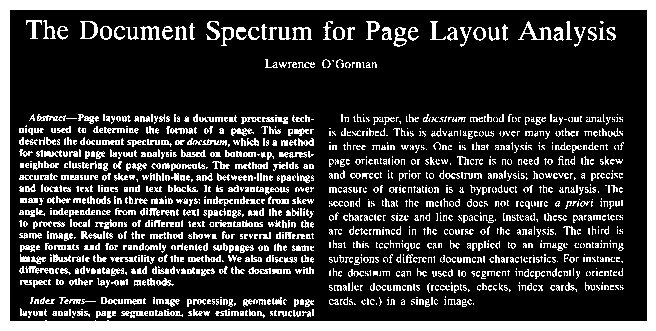

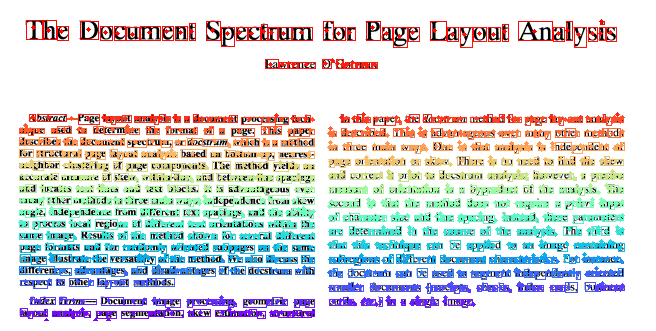

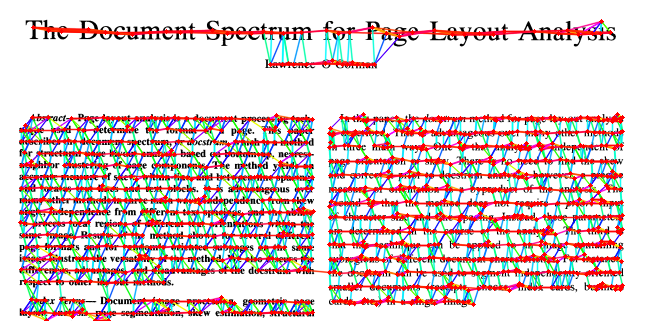

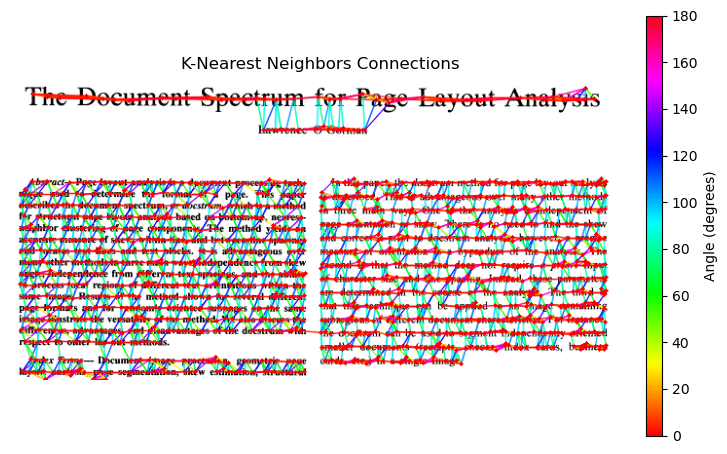

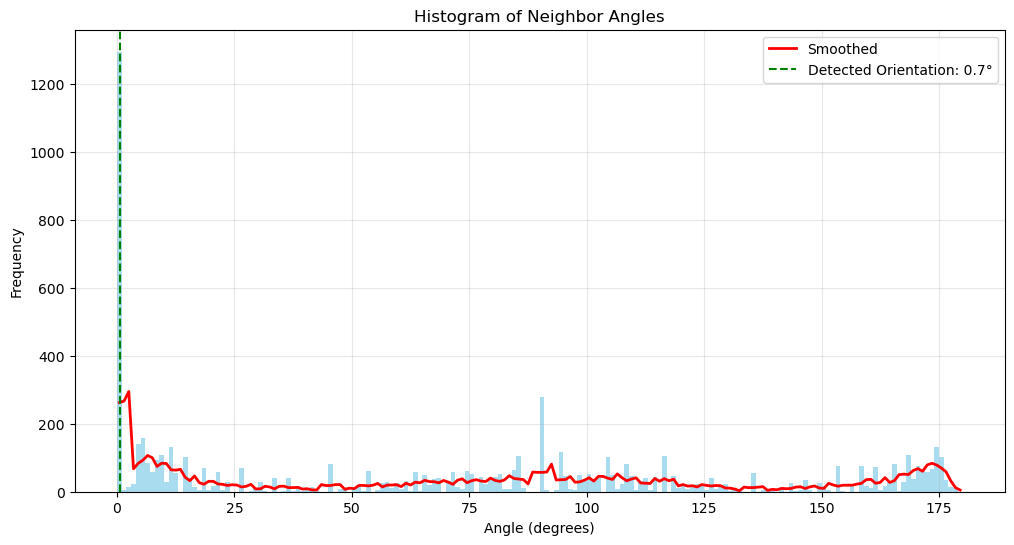

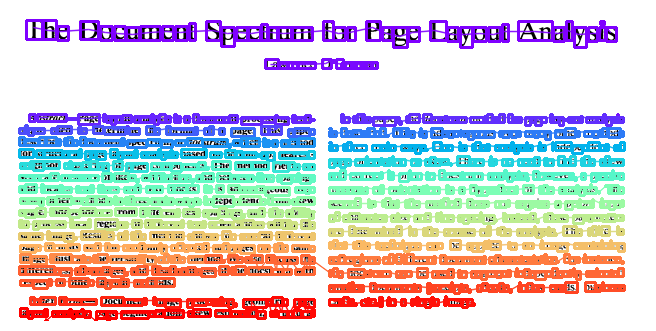

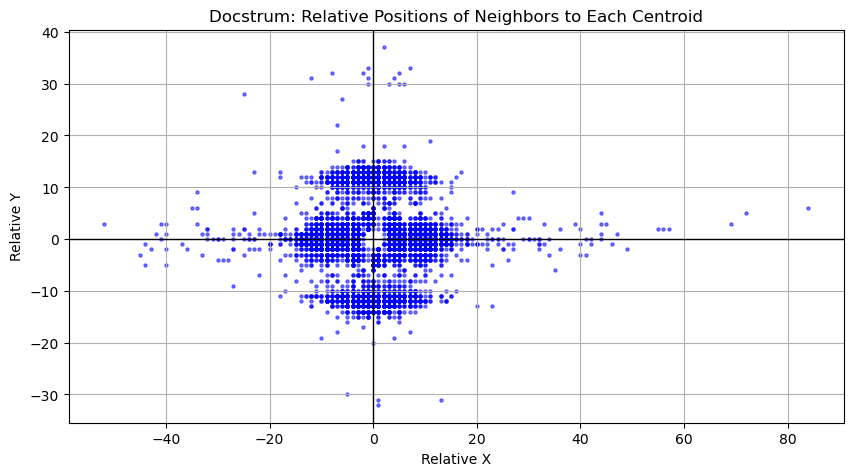

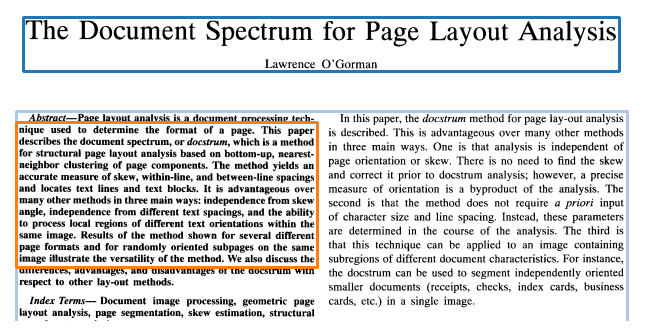

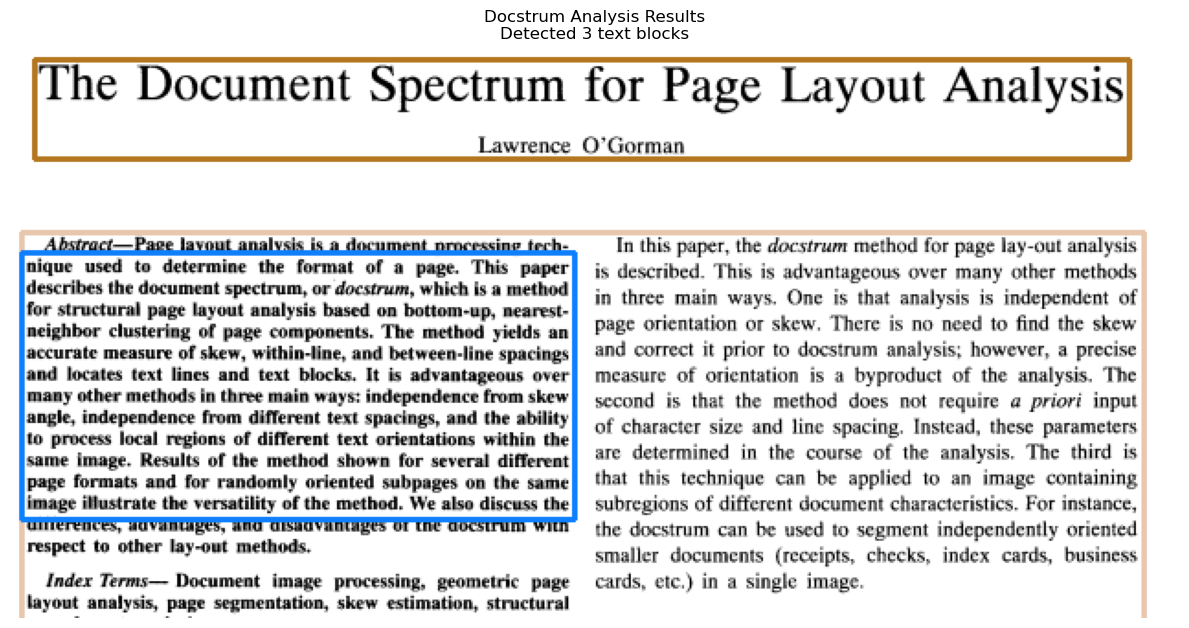

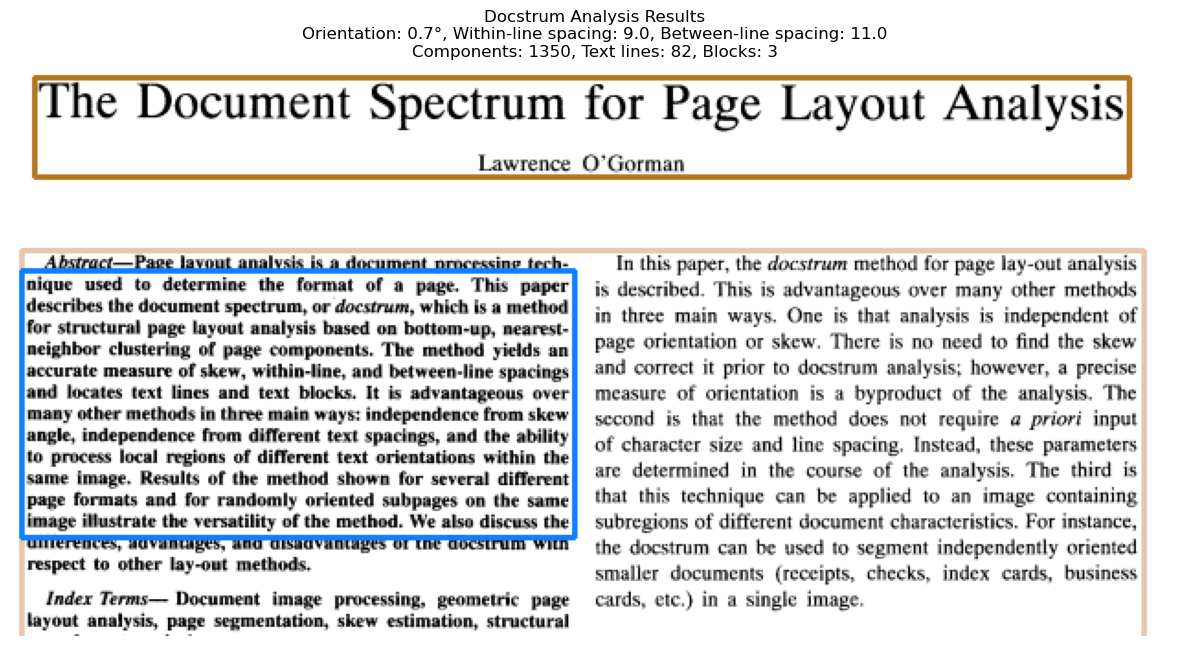


Processed test1:
- Orientation: 0.7°
- Within-line spacing: 9.0 pixels
- Between-line spacing: 11.0 pixels
- Found 1350 components
- Grouped into 82 text lines
- Detected 3 text blocks
- Visualizations saved to output_test

Processed test1:
- Initial orientation: 0.5°
- Final orientation: 0.7°
- Within-line spacing: 9.0 pixels
- Between-line spacing: 11.0 pixels
- Found 1350 components
- Grouped into 82 text lines
- Detected 3 text blocks
- Output saved to output_test


In [25]:


input_path = 'test1.png'
output_dir = 'output_test'
k_nearest = 5
angle_threshold = 30
smoothing_window = 25
visualization = 'detailed'
kfill_threshold = 5
max_iterations = 10


# Initialize docstrum
docstrum = Docstrum(k_nearest=k_nearest, angle_threshold=angle_threshold)

# Process single image or directory
if os.path.isfile(input_path):
    # Single image processing
    image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Error: Could not load image {input_path}")
    
    filename = os.path.splitext(os.path.basename(input_path))[0]
    components, text_lines, orientation, blocks, spacings, binary, initial_orientation, neighbors_info = docstrum.process(image, kfill_threshold = kfill_threshold, max_iterations = max_iterations)
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Choose visualization level
    if visualization == 'detailed':
        # Full visualization of all steps
        docstrum.visualize_all_results(image, components, text_lines, blocks, 
                                        orientation, spacings, binary, neighbors_info,
                                        output_dir, filename)
    elif visualization == 'standard':
        # Standard visualization - just blocks and summary
        docstrum.visualize_preprocessing(image, binary, output_dir, filename)
        docstrum.visualize_text_lines(image, components, text_lines, output_dir, filename)
        docstrum.visualize_blocks(image, components, blocks, output_dir, filename)
    else:  # 'minimal'
        # Minimal visualization - just blocks
        docstrum.visualize_blocks(image, components, blocks, output_dir, filename)
    
    # Always print summary information
    within_line_spacing, between_line_spacing = spacings
    print(f"\nProcessed {filename}:")
    print(f"- Initial orientation: {initial_orientation:.1f}°")
    print(f"- Final orientation: {orientation:.1f}°")
    print(f"- Within-line spacing: {within_line_spacing:.1f} pixels")
    print(f"- Between-line spacing: {between_line_spacing:.1f} pixels")
    print(f"- Found {len(components)} components")
    print(f"- Grouped into {len(text_lines)} text lines")
    print(f"- Detected {len(blocks)} text blocks")
    print(f"- Output saved to {output_dir}")
    
elif os.path.isdir(input_path):
    # Directory processing
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    processed = 0
    errors = 0
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    for filename in os.listdir(input_path):
        if os.path.splitext(filename)[1].lower() in image_extensions:
            image_path = os.path.join(input_path, filename)
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            
            if image is None:
                print(f"Error: Could not load image {image_path}")
                errors += 1
                continue
            
            try:
                # Process image
                base_filename = os.path.splitext(filename)[0]
                components, text_lines, orientation, blocks, spacings, binary, initial_orientation, neighbors_info = docstrum.process(image, kfill_threshold = kfill_threshold, max_iterations = max_iterations)
                
                # Choose visualization level
                if visualization == 'detailed':
                    # Full visualization of all steps
                    docstrum.visualize_all_results(image, components, text_lines, blocks, 
                                                    orientation, spacings, binary, neighbors_info,
                                                    output_dir, base_filename)
                elif visualization == 'standard':
                    # Standard visualization - just blocks and summary
                    docstrum.visualize_preprocessing(image, binary, output_dir, base_filename)
                    docstrum.visualize_text_lines(image, components, text_lines, output_dir, base_filename)
                    docstrum.visualize_blocks(image, components, blocks, output_dir, base_filename)
                else:  # 'minimal'
                    # Minimal visualization - just blocks
                    docstrum.visualize_blocks(image, components, blocks, output_dir, base_filename)
                
                # Always print summary information for each image
                within_line_spacing, between_line_spacing = spacings
                print(f"\nProcessed {filename}:")
                print(f"- Initial orientation: {initial_orientation:.1f}°")
                print(f"- Final orientation: {orientation:.1f}°")
                print(f"- Within-line spacing: {within_line_spacing:.1f} pixels")
                print(f"- Between-line spacing: {between_line_spacing:.1f} pixels")
                print(f"- Found {len(components)} components")
                print(f"- Grouped into {len(text_lines)} text lines")
                print(f"- Detected {len(blocks)} text blocks")
                
                processed += 1
                
            except Exception as e:
                print(f"Error processing {filename}: {str(e)}")
                errors += 1
    
    print(f"\nProcessing summary:")
    print(f"- Successfully processed: {processed} images")
    print(f"- Errors: {errors} images")
    print(f"- Output saved to: {output_dir}")
    
else:
    print(f"Error: {input_path} is not a valid file or directory")

